(Deitel&Deitel 7.22) (Pandas: Series) Perform the following tasks with pandas Series:

a) Create a Series from the list [7,11,13,17].

b) Create a Series with five elements that are all 100.0.

c) Create a Series with 20 elements that are all random numbers in the range 0 to 100. Use method describe to produce the Series’ basic descriptive statistics.

d) Create a Series called temperatures of the floating-point values 98.6, 98.9, 100.2 and 97.9. Using the index keyword argument, specify the custom indices 'Julie', 'Charlie', 'Sam' and 'Andrea'.

e) Form a dictionary from the names and values in Part (d), then use it to initialize a Series.


In [1]:
import pandas as pd
from numpy import random

In [15]:
#a series from a list
series_from_list = pd.Series([7,11,13,17])
#a Series of 5 number 
series_five = pd.Series(100, range(5))
#a series from an array of 20 random numbers
series_random = pd.Series(random.randint(100, size=(20)))
print(series_random.describe())
#series with str index
temperatures = pd.Series(([98.6, 98.9, 100.2, 97.9]), index=['Julie', 'Charlie', 'Sam', 'Andrea'])
mydict = {}

for index, value in temperatures.items():
    mydict[index] = value
mydict




count    20.000000
mean     44.100000
std      27.343622
min      10.000000
25%      23.250000
50%      36.500000
75%      70.750000
max      96.000000
dtype: float64


{'Julie': 98.6, 'Charlie': 98.9, 'Sam': 100.2, 'Andrea': 97.9}

(Deitel&Deitel 7.23) (Pandas: DataFrames) Perform the following tasks with pandas DataFrames:

a) Create a DataFrame named temperatures from a dictionary of three temperature readings each for 'Maxine', 'James' and 'Amanda'.

b) Recreate the DataFrame temperatures in Part (a) with custom indices using the index keyword argument and a list containing 'Morning', 'Afternoon' and 'Evening'.

c) Select from temperatures the column of temperature readings for 'Maxine'.

d) Select from temperatures the row of 'Morning' temperature readings.

e) Select from temperatures the rows for 'Morning' and 'Evening' temperature readings.

f) Select from temperatures the columns of temperature readings for 'Amanda' and 'Maxine'.

g) Select from temperatures the elements for 'Amanda' and 'Maxine' in the 'Morning' and 'Afternoon'.

h) Use the describe method to produce temperatures’ descriptive statistics.

i) Transpose temperatures.

j) Sort temperatures so that its column names are in alphabetical order.

In [33]:
temperatures = pd.DataFrame({'Maxine':[36.7, 36.9, 36.8], 'James':[36.9, 36.9, 37.2], 'Amanda':[36.8, 37.1, 36.4]})
temperatures.index=['Morning', 'Afternoon', 'Evening']
print(temperatures)
#c
print(temperatures.loc[:,['Maxine']])
#d
print('\n')
print(temperatures.loc['Morning'])
#e
print('\n')
print(temperatures.loc[['Morning', 'Evening']])
#f
print('\n')
print(temperatures.loc[:,['Amanda', 'Maxine']])
#g
print('\n')
print(temperatures.loc[['Morning', 'Evening'],['Amanda', 'Maxine']])
#h
print('\n')
print(temperatures.describe())
#i
print('\n')
print(temperatures.T)
#j
temperatures.sort_index(axis=1)

           Maxine  James  Amanda
Morning      36.7   36.9    36.8
Afternoon    36.9   36.9    37.1
Evening      36.8   37.2    36.4
           Maxine
Morning      36.7
Afternoon    36.9
Evening      36.8


Maxine    36.7
James     36.9
Amanda    36.8
Name: Morning, dtype: float64


         Maxine  James  Amanda
Morning    36.7   36.9    36.8
Evening    36.8   37.2    36.4


           Amanda  Maxine
Morning      36.8    36.7
Afternoon    37.1    36.9
Evening      36.4    36.8


         Amanda  Maxine
Morning    36.8    36.7
Evening    36.4    36.8


       Maxine      James     Amanda
count    3.00   3.000000   3.000000
mean    36.80  37.000000  36.766667
std      0.10   0.173205   0.351188
min     36.70  36.900000  36.400000
25%     36.75  36.900000  36.600000
50%     36.80  36.900000  36.800000
75%     36.85  37.050000  36.950000
max     36.90  37.200000  37.100000


        Morning  Afternoon  Evening
Maxine     36.7       36.9     36.8
James      36.9       36.9     37.2
Amanda  

,Amanda,James,Maxine
Morning,36.8,36.9,36.7
Afternoon,37.1,36.9,36.9
Evening,36.4,37.2,36.8


(Aggarwal 2.3) Download the Arrythmia data set from the UCI Machine Learning Repository.

Normalize all records to a mean of 0 and a standard deviation of 1.

Discretize each numerical attribute into:

1.   10 equiwidth ranges.
2.   10 equidepth ranges.

Plot histograms of a few features in both cases (1) and (2). Results are coherent with your expectations?


Dataset caricato con successo
Normalizzazione completata

--- Analisi Feature 178 ---
Soglie calcolate: [np.float64(-3.5365131966311476), -1.1426361559018214, -0.786837092994909, -0.5613471027303071, -0.3072214172179469, -0.10226683311701465, 0.1994359013617271, 0.4770783388715129, 0.923289714499701, 1.3918660631002755, 3.259010761100618]


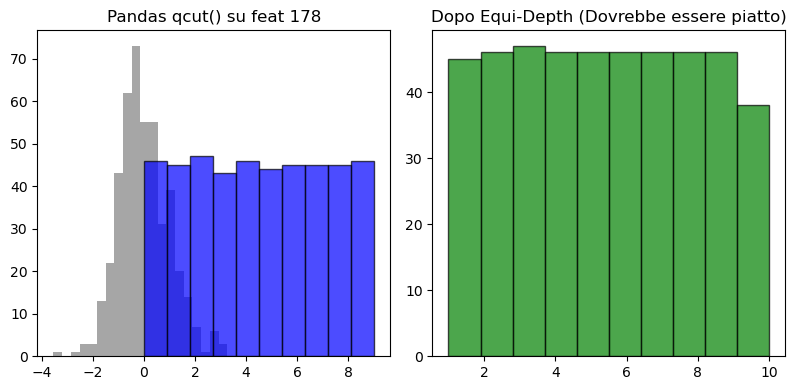

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

#======================
# 1. CARICAMENTO DATI
#======================

#Creiamo una lista di etichette per le colonne: numeri da 0 a 278, più la colonna 'class'
labels=list(range(279)) + ['class']

#carichiamo il dataset
#impostiamo noi le intestazione tramite names
try:
    df = pd.read_csv('_arrhythmia/arrhythmia.csv', names=labels)
    print('Dataset caricato con successo')
except FileNotFoundError:
    print('Errore file non trovato.')

#=======================
# 2. PULIZIA DEI DATI(MANUALE)
#=======================

#Approccio manuale, useremo doppi cicli for al posto di

# CODICE VELOCE
# 1. Sostituisce '?' con 0 in tutto il DataFrame in un colpo solo
# df.replace('?', 0, inplace=True)

#sostituiamo i valori indefiniti con 0

# CODICE MANUALE

# df.shape[1] sono le colonne, df.shape[0] sono le righe
for col in range(df.shape[1]):
    for row in range(df.shape[0]):
        #.iat e' il metodo piu' veloce per accedere al singolo elemento
        if df.iat[row,col]=='?':
            df.iat[row,col]=0 #effettuiamo la sostituzione 

df = df.astype(float)


#=====================
# 3. NORMALIZZAZIONE (Z-SCORE)
#=====================

#Vogliamo che ogni colonna abbia media 0 e deviazione standard 1

#Formula = (Valore - media) / deviazioneStandard

s_df = (df - df.mean()) / df.std()

print('Normalizzazione completata')


#=====================
# 4. FUNZIONE DI DISCRETIZZAZIONE
#=====================

def discretize_column(df_input, col, nbin=10, mode='equiwidth'):
    """
    Funzione manuale per dividere una colonna continua in intervalli (bin).
    df_input: Il DataFrame su cui lavorare
    col: L'indice della colonna da discretizzare
    nbin: Numero di intervalli desiderati
    mode: 'equiwidth' (stessa larghezza) o 'equidepth' (stessa frequenza)
    """

    #creo una copia per non agire sul dataframe passato
    df = df_input

    if mode=='equiwidth':
        
        #Calcolo del range massimo dei dati (Max-Min)
        
        range_val =  df.iloc[:,col].max() - df.iloc[:, col].min()

        #Formula di proporzione
        #Trasforma il valore in un indice intero tra 0 e nbin-1
        df.iloc[:, col] = (df.iloc[:, col]-df.iloc[:, col].min()) * nbin // range_val 

    if mode=='equidepth':

        # A. aggiunta di rumore(jittering)
        # Fondamentale, poiche' senza l'algoritmo non funzionerebbe: se abbiamo tanti valori identici
        # (es. tanti 0) non potremo dividerli in bin diversi. Aggiungendo un numero casuale piccolissimo
        # li rendiamo unici e ordinabili

        for i in range (df.iloc[:,col].size):
            df.iloc[i,col] += random.random() * 0.01

        # B. Ordinamento 
        # Ordiniamo i valori per capire dove tagliare

        sorted_val = df.iloc[:,col].sort_values()

        # C. Calcolo soglie(intervalli)

        intervals = [sorted_val.iat[0]] # Il primo intervallo inizia col valore minimo 
        bin_size = (df.iloc[:, col].size) / nbin #quanti elementi devono stare in ogni bin

        count = 0
        for d in sorted_val:
            count += 1
            # Quando il contatore raggiunge la dimensione del bin, creiamo un taglio
            if count > bin_size:
                count = 0
                intervals.append(d) #Salviamo il valore di soglia

        intervals.append(d) # Aggiungiamo l'ultimo valore massimo 
        print(f"Soglie calcolate: {intervals}")

        # D. Assegnazione manuale
        for i in range(df.iloc[:, col].size): #per ogni riga
            for j in range(1, len(intervals)): #controlla in quale intervallo cade
                if(df.iat[i,col] < intervals[j]):
                    df.iat[i,col]=j # Assegna l'ID del bin (1, 2, 3...)
                    break # Trovato il bin, passa alla prossima riga
                
                
# ==========================================
# 5. TEST E VISUALIZZAZIONE
# ==========================================        
            
#Scegliamo una colonna 
feature_idx = 178

print(f"\n--- Analisi Feature {feature_idx} ---")
# Visualizziamo l'istogramma prima della discretizzazione
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(s_df[feature_idx], bins=20, color='gray', alpha=0.7)
plt.title('Dati originali normalizzati')

# Eseguiamo Equi-Depth (Modifica il dataframe s_df "in place")
# Nota: stiamo passando s_df, quindi verrà modificato permanentemente!
# Per sicurezza didattica, ricalcolo s_df pulito o lavoro su una copia sarebbe meglio,
# ma seguo la logica del prof che modifica s_df.
discretize_column(s_df, feature_idx, nbin=10, mode='equidepth')

# Visualizziamo DOPO Equi-Depth
plt.subplot(1, 3, 2)
plt.hist(s_df[feature_idx], bins=10, color='green', edgecolor='black', alpha=0.7)
plt.title("Dopo Equi-Depth (Dovrebbe essere piatto)")

# --- CONFRONTO CON PANDAS NATIVO (qcut) ---
# Usiamo un'altra colonna per far vedere come lo fa Pandas automaticamente

feature_test_pandas=178
categories = pd.qcut(df[feature_test_pandas], q=10, labels=False, duplicates='drop')

plt.subplot(1,3,1)
plt.hist(categories, bins=10, color='blue', edgecolor='black', alpha=0.7)
plt.title(f"Pandas qcut() su feat {feature_test_pandas}")

plt.tight_layout()
plt.show()


La discretizzazione si può fare anche con le funzioni di Pandas cut() e qcut()

https://www.kaggle.com/code/mrbisht/discretization-continuous-variables

https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
